Proses 1: Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_palette("muted")
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

Proses 2: Mengambil dan Menjalankan Dataset

In [6]:
df = pd.read_csv('../data/application_train.csv')
print(f"Dataset Berhasil Dimuat Shape: {df.shape}")

Dataset Berhasil Dimuat Shape: (307511, 122)


Proses 3: Data Understanding

In [10]:
print("Informasi Dataset:\n")
print(f"Jumlah baris   : {df.shape[0]:,}")
print(f"Jumlah kolom   : {df.shape[1]}")
print("\nTipe Data:")
print(df.dtypes.value_counts())

print("\n5 Baris Pertama:")
df.head()

Informasi Dataset:

Jumlah baris   : 307,511
Jumlah kolom   : 122

Tipe Data:
float64    65
int64      41
str        16
Name: count, dtype: int64

5 Baris Pertama:


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
# Statistik Deskriptif
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


In [13]:
# Proses Handle Missing Values
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing / len(df) * 100).round(2)

missing_table = pd.DataFrame({
    'Missing Values': missing,
    'Persentase (%)': missing_percent
})

print("Kolom dengan Missing Values Terbanyak:")
missing_table.head(10)

Kolom dengan Missing Values Terbanyak:


,Missing Values,Persentase (%)
COMMONAREA_AVG,214865,69.87
COMMONAREA_MODE,214865,69.87
COMMONAREA_MEDI,214865,69.87
NONLIVINGAPARTMENTS_MEDI,213514,69.43
NONLIVINGAPARTMENTS_MODE,213514,69.43
NONLIVINGAPARTMENTS_AVG,213514,69.43
FONDKAPREMONT_MODE,210295,68.39
LIVINGAPARTMENTS_AVG,210199,68.35
LIVINGAPARTMENTS_MEDI,210199,68.35
LIVINGAPARTMENTS_MODE,210199,68.35


Proses 4: Target Distribution

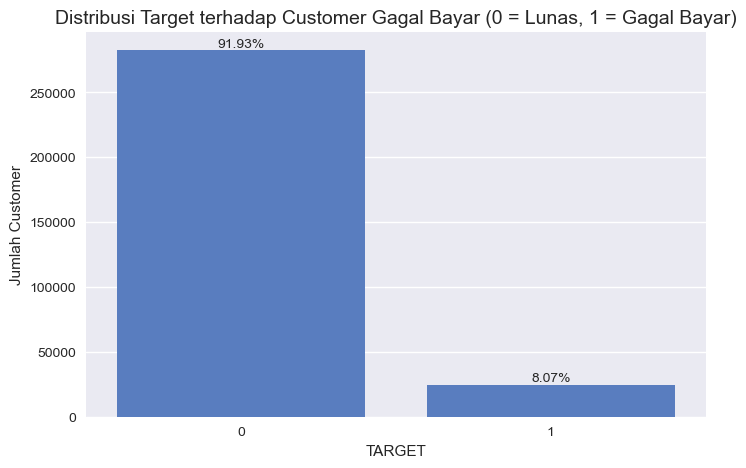

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


In [17]:
# Analisis Distribusi Target Terhadap Customer Gagal Bayar
plt.figure(figsize=(8,5))
ax = sns.countplot(data=df, x='TARGET')
plt.title('Distribusi Target terhadap Customer Gagal Bayar (0 = Lunas, 1 = Gagal Bayar)', fontsize=14)
plt.xlabel('TARGET')
plt.ylabel('Jumlah Customer')

total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.2f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width()/2, p.get_height()), 
                ha='center', va='bottom')

plt.show()

print(df['TARGET'].value_counts(normalize=True) * 100)

Proses 5: Analisis Numerik

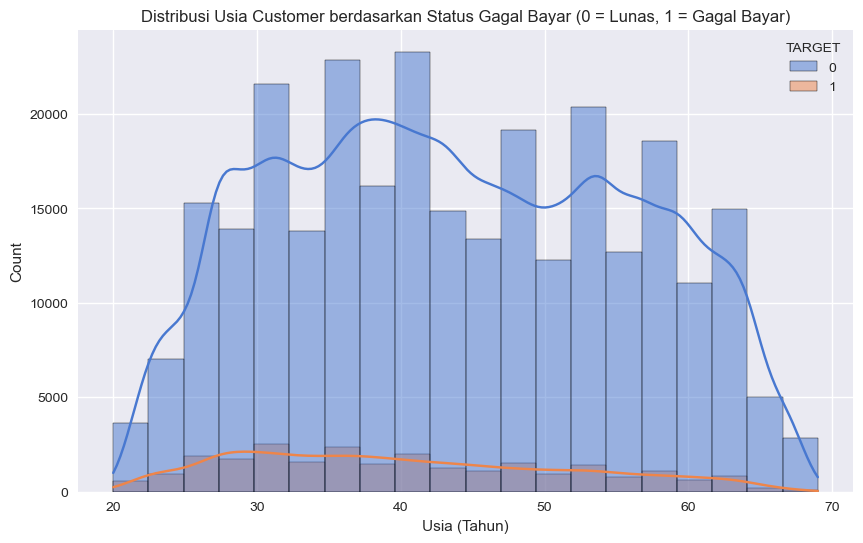

In [18]:
# Analisis Distribusi Usia
df['USIA'] = -df['DAYS_BIRTH'] // 365

plt.figure(figsize=(10,6))
sns.histplot(data=df, x='USIA', hue='TARGET', bins=20, kde=True)
plt.title('Distribusi Usia Customer berdasarkan Status Gagal Bayar (0 = Lunas, 1 = Gagal Bayar)')
plt.xlabel('Usia (Tahun)')
plt.show()

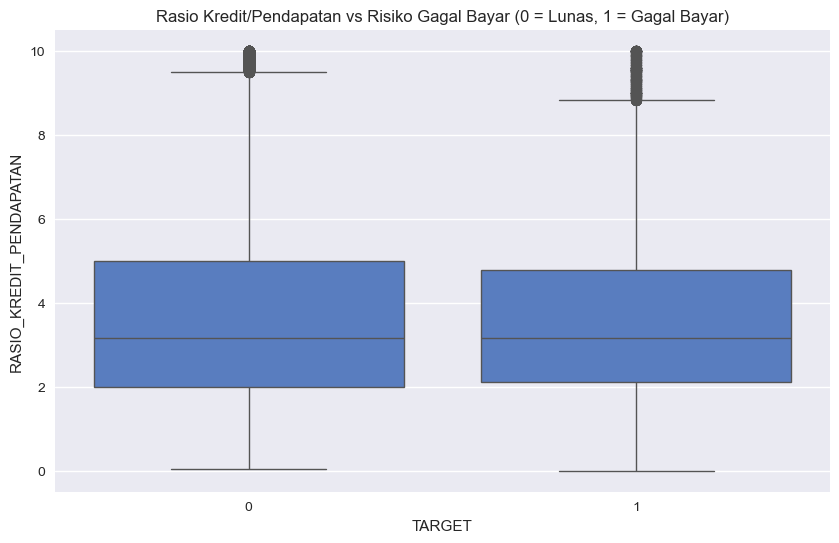

In [26]:
# Analisis Rasio Kredit terhadap Pendapatan
df['RASIO_KREDIT_PENDAPATAN'] = df['AMT_CREDIT'] / (df['AMT_INCOME_TOTAL'] + 1)

plt.figure(figsize=(10,6))
sns.boxplot(x='TARGET', y='RASIO_KREDIT_PENDAPATAN', 
            data=df[df['RASIO_KREDIT_PENDAPATAN'] < 10])  # filter outlier
plt.title('Rasio Kredit/Pendapatan vs Risiko Gagal Bayar (0 = Lunas, 1 = Gagal Bayar)')
plt.show()

Proses 6: Analisis Kategorikal

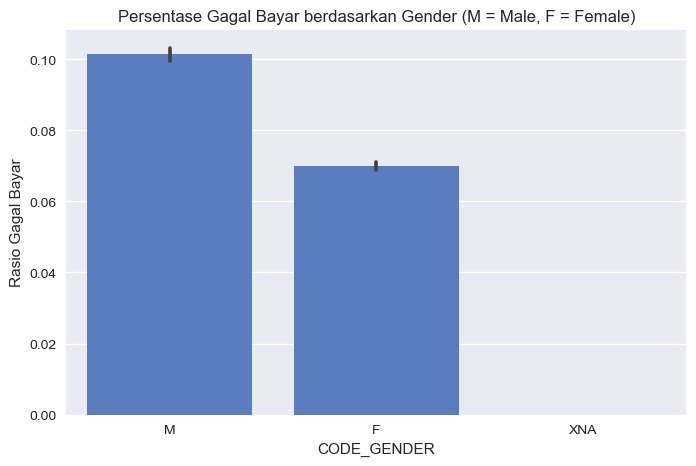

In [28]:
# Analisis Customer berdasarkan Gender
plt.figure(figsize=(8,5))
sns.barplot(x='CODE_GENDER', y='TARGET', data=df)
plt.title('Persentase Gagal Bayar berdasarkan Gender (M = Male, F = Female)')
plt.ylabel('Rasio Gagal Bayar')
plt.show()

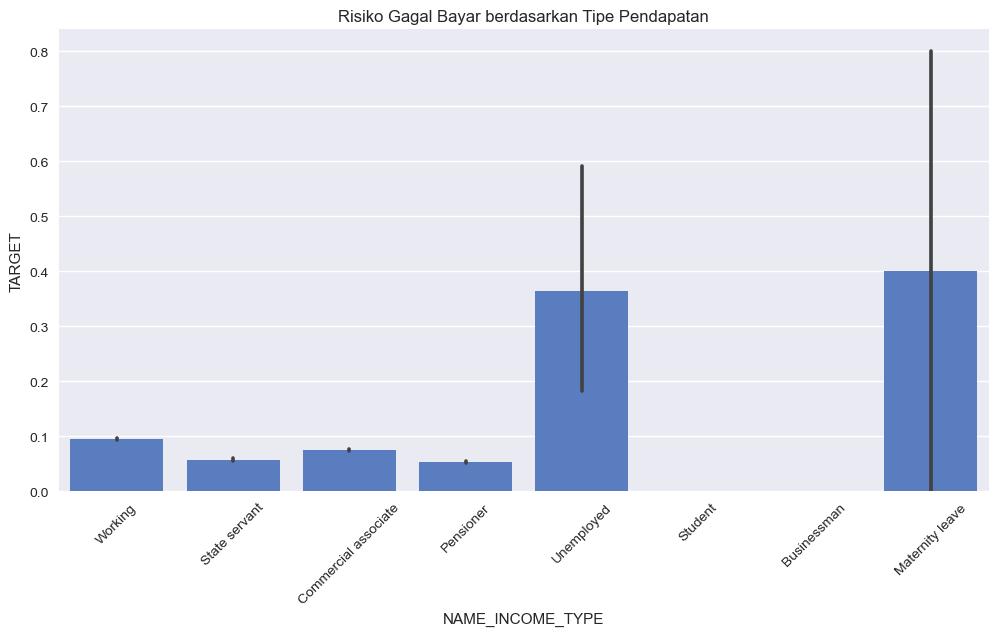

In [ ]:
# Analisis Customer berdasarkan Pendapatan
plt.figure(figsize=(12,6))
sns.barplot(x='NAME_INCOME_TYPE', y='TARGET', data=df)
plt.title('Risiko Gagal Bayar berdasarkan Tipe Pendapatan')
plt.xticks(rotation=45)
plt.show()

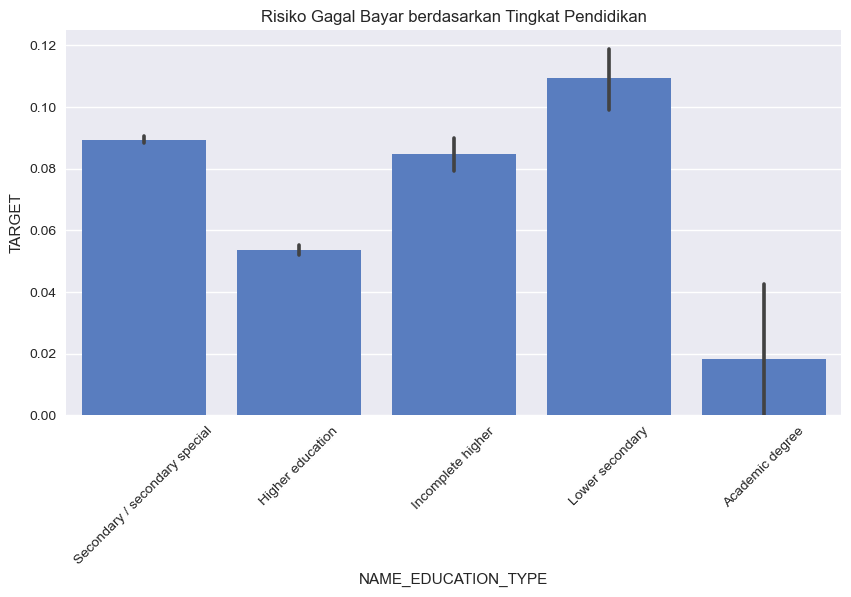

In [24]:
# Analisis Customer berdasarkan Pendidikan
plt.figure(figsize=(10,5))
sns.barplot(x='NAME_EDUCATION_TYPE', y='TARGET', data=df)
plt.title('Risiko Gagal Bayar berdasarkan Tingkat Pendidikan')
plt.xticks(rotation=45)
plt.show()

Proses 7: Correlation antar Fitur

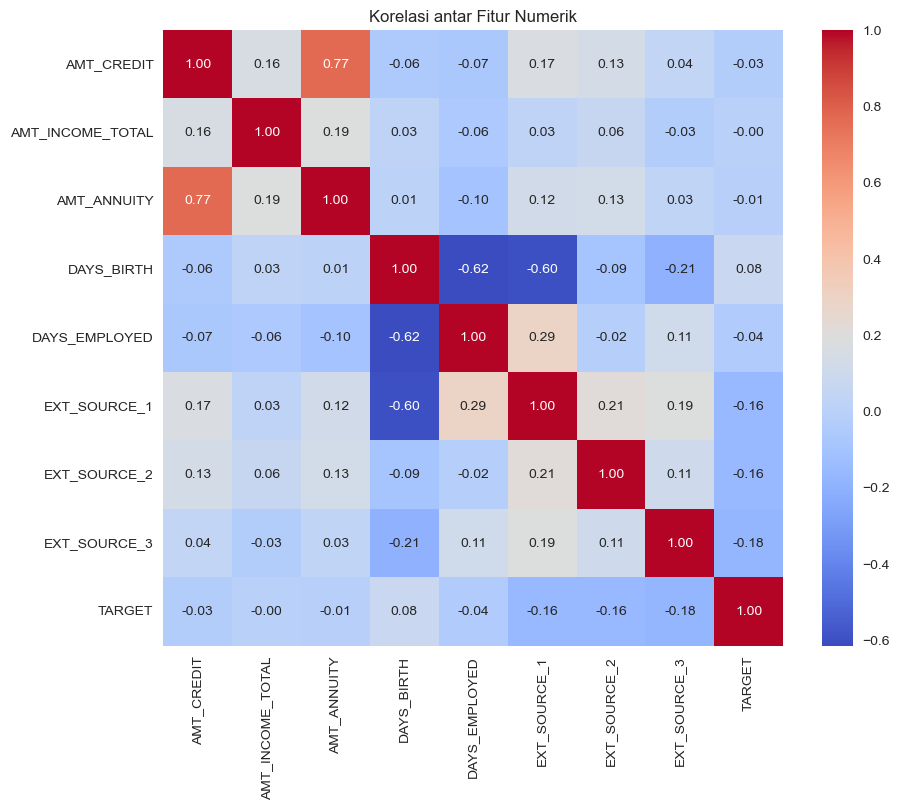

In [29]:
# Korelasi Heatmap
numerical_features = ['AMT_CREDIT', 'AMT_INCOME_TOTAL', 'AMT_ANNUITY', 
                     'DAYS_BIRTH', 'DAYS_EMPLOYED', 'EXT_SOURCE_1', 
                     'EXT_SOURCE_2', 'EXT_SOURCE_3', 'TARGET']

plt.figure(figsize=(10,8))
sns.heatmap(df[numerical_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi antar Fitur Numerik')
plt.show()